# STEP 0 — Notebook Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better visuals
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)


ModuleNotFoundError: No module named 'pandas'

# STEP 1 — Load the Datasets

In [ ]:
train_df = pd.read_csv("train_dataset.csv")
test_df  = pd.read_csv("test_dataset.csv")


# STEP 2 — First Look at the Data

In [ ]:
train_df.head()




,LTE/5g Category,Time,Packet Loss Rate,Packet delay,IoT,LTE/5G,GBR,Non-GBR,AR/VR/Gaming,Healthcare,Industry 4.0,IoT Devices,Public Safety,Smart City & Home,Smart Transportation,Smartphone,slice Type
0,14,0,0.000001,10,1,0,0,1,0,0,0,0,1,0,0,0,3
1,18,20,0.001000,100,0,1,1,0,1,0,0,0,0,0,0,0,1
2,17,14,0.000001,300,0,1,0,1,0,0,0,0,0,0,0,1,1
3,3,17,0.010000,100,0,1,0,1,0,0,0,0,0,0,0,1,1
4,9,4,0.010000,50,1,0,0,1,0,0,0,0,0,1,0,0,2


In [ ]:
train_df.shape


(31583, 17)

In [ ]:
train_df.columns


Index(['LTE/5g Category', 'Time', 'Packet Loss Rate', 'Packet delay', 'IoT',
       'LTE/5G', 'GBR', 'Non-GBR', 'AR/VR/Gaming', 'Healthcare',
       'Industry 4.0', 'IoT Devices', 'Public Safety', 'Smart City & Home',
       'Smart Transportation', 'Smartphone', 'slice Type'],
      dtype='str')

In [ ]:
test_df.head()


,LTE/5g Category,Time,Packet Loss Rate,Packet delay,IoT,LTE/5G,GBR,Non-GBR,AR/VR/Gaming,Healthcare,Industry 4.0,IoT Devices,Public Safety,Smart City & Home,Smart Transportation,Smartphone
0,15,17,0.001000,100,0,1,1,0,1,0,0,0,0,0,0,0
1,14,18,0.000001,10,1,0,0,1,0,0,0,0,0,0,1,0
2,11,7,0.001000,50,1,0,1,0,0,0,1,0,0,0,0,0
3,20,14,0.001000,50,1,0,1,0,0,0,1,0,0,0,0,0
4,2,22,0.001000,50,0,1,0,1,1,0,0,0,0,0,0,0


In [ ]:
test_df.shape

(31584, 16)

In [ ]:
test_df.columns

Index(['LTE/5g Category', 'Time', 'Packet Loss Rate', 'Packet delay', 'IoT',
       'LTE/5G', 'GBR', 'Non-GBR', 'AR/VR/Gaming', 'Healthcare',
       'Industry 4.0', 'IoT Devices', 'Public Safety', 'Smart City & Home',
       'Smart Transportation', 'Smartphone'],
      dtype='str')

# STEP 3 — Data Types & Basic Info

In [ ]:
train_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 31583 entries, 0 to 31582
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   LTE/5g Category       31583 non-null  int64  
 1   Time                  31583 non-null  int64  
 2   Packet Loss Rate      31583 non-null  float64
 3   Packet delay          31583 non-null  int64  
 4   IoT                   31583 non-null  int64  
 5   LTE/5G                31583 non-null  int64  
 6   GBR                   31583 non-null  int64  
 7   Non-GBR               31583 non-null  int64  
 8   AR/VR/Gaming          31583 non-null  int64  
 9   Healthcare            31583 non-null  int64  
 10  Industry 4.0          31583 non-null  int64  
 11  IoT Devices           31583 non-null  int64  
 12  Public Safety         31583 non-null  int64  
 13  Smart City & Home     31583 non-null  int64  
 14  Smart Transportation  31583 non-null  int64  
 15  Smartphone            31583 no

# STEP 4 — Target Variable Analysis (slice Type)

In [ ]:
train_df["slice Type"].value_counts()

slice Type
1    16799
3     7392
2     7392
Name: count, dtype: int64

In [ ]:
train_df["slice Type"].value_counts(normalize=True) * 100


slice Type
1    53.190007
3    23.404996
2    23.404996
Name: proportion, dtype: float64

# Visualization

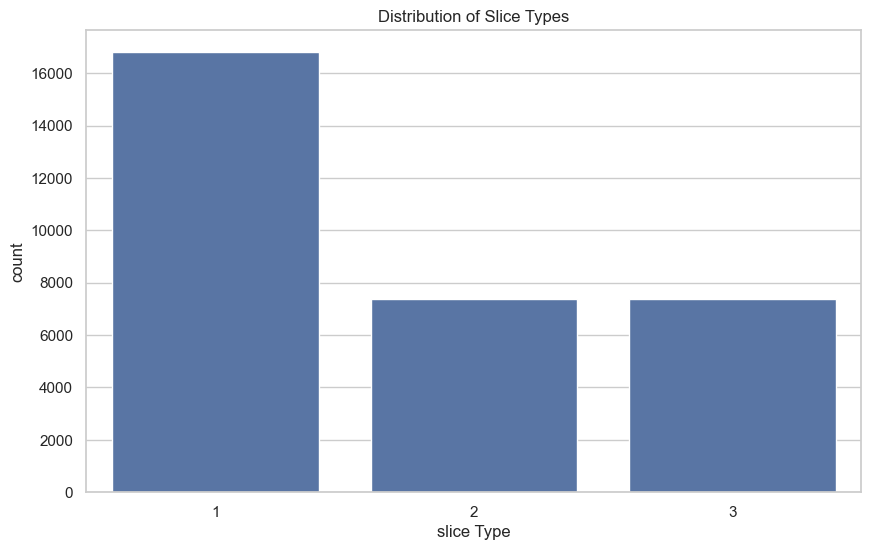

In [ ]:
sns.countplot(x="slice Type", data=train_df)
plt.title("Distribution of Slice Types")
plt.show()


# STEP 5 — Descriptive Statistics

In [ ]:
train_df.describe()


,LTE/5g Category,Time,Packet Loss Rate,Packet delay,IoT,LTE/5G,GBR,Non-GBR,AR/VR/Gaming,Healthcare,Industry 4.0,IoT Devices,Public Safety,Smart City & Home,Smart Transportation,Smartphone,slice Type
count,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000,31583.000000
mean,10.974923,11.476459,0.003079,114.126745,0.468100,0.531900,0.441187,0.558813,0.106291,0.057943,0.116107,0.057879,0.059716,0.117722,0.058734,0.425609,1.702150
std,6.053641,6.915643,0.004344,106.320976,0.498989,0.498989,0.496537,0.496537,0.308215,0.233639,0.320358,0.233519,0.236963,0.322283,0.235130,0.494443,0.822956
min,1.000000,0.000000,0.000001,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,6.000000,6.000000,0.000001,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,11.000000,11.000000,0.001000,75.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,16.000000,17.000000,0.010000,150.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000
max,22.000000,23.000000,0.010000,300.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000


# STEP 6 — Missing Values Check

In [ ]:
train_df.isnull().sum()


LTE/5g Category         0
Time                    0
Packet Loss Rate        0
Packet delay            0
IoT                     0
LTE/5G                  0
GBR                     0
Non-GBR                 0
AR/VR/Gaming            0
Healthcare              0
Industry 4.0            0
IoT Devices             0
Public Safety           0
Smart City & Home       0
Smart Transportation    0
Smartphone              0
slice Type              0
dtype: int64

In [ ]:
test_df.isnull().sum()

LTE/5g Category         0
Time                    0
Packet Loss Rate        0
Packet delay            0
IoT                     0
LTE/5G                  0
GBR                     0
Non-GBR                 0
AR/VR/Gaming            0
Healthcare              0
Industry 4.0            0
IoT Devices             0
Public Safety           0
Smart City & Home       0
Smart Transportation    0
Smartphone              0
dtype: int64

# STEP 7 — Duplicate Rows

In [ ]:
train_df.duplicated().sum()


np.int64(22625)

In [ ]:
train_df = train_df.drop_duplicates()

# STEP 8 — Feature Distributions (Univariate Analysis)

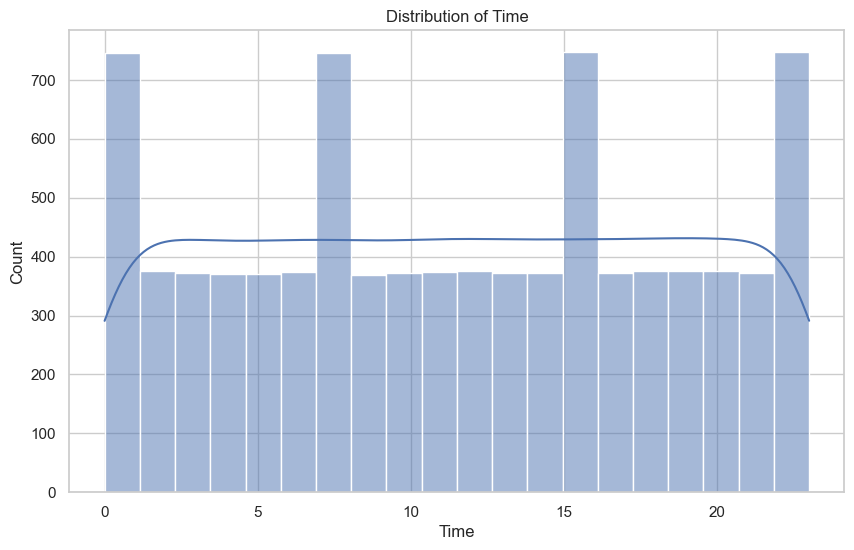

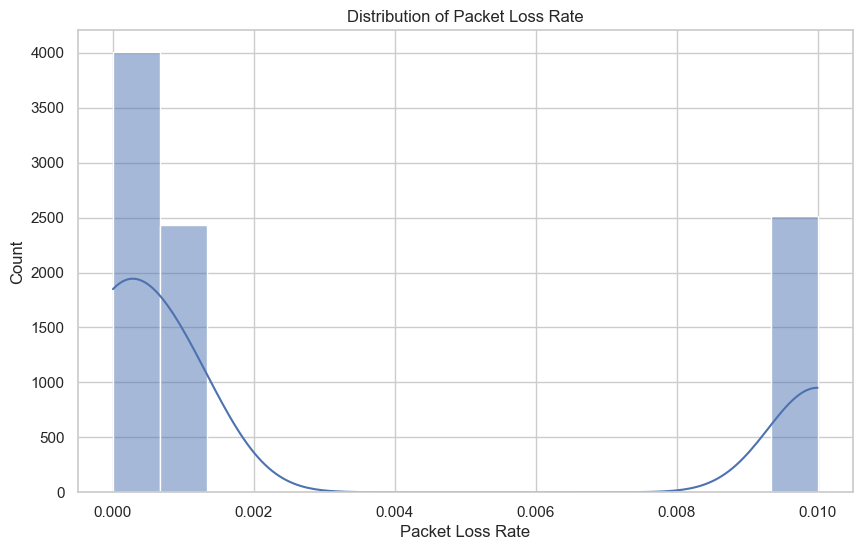

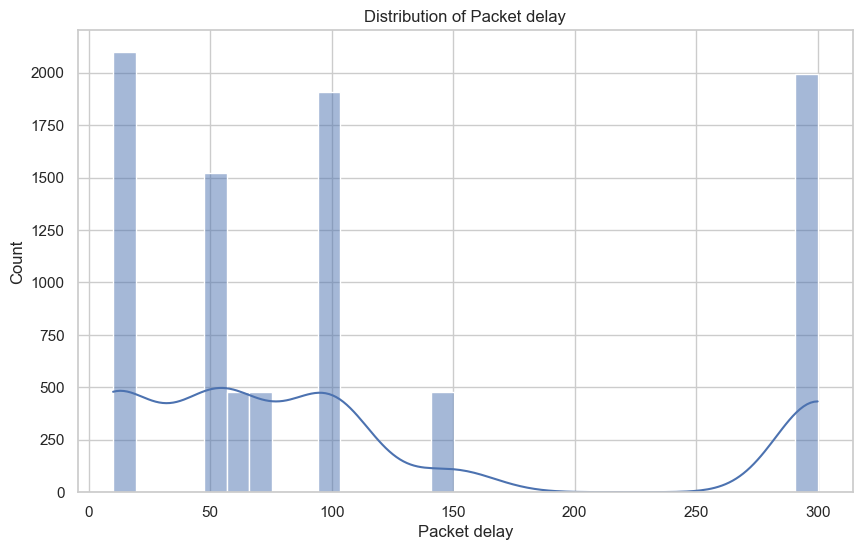

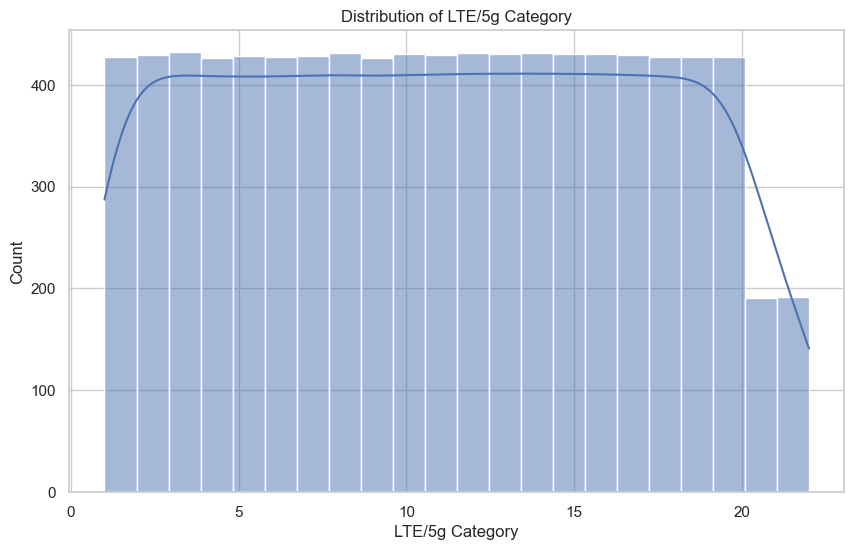

In [ ]:
numerical_features = [
    "Time", "Packet Loss Rate", "Packet delay", "LTE/5g Category"
]

for col in numerical_features:
    sns.histplot(train_df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


# STEP 9 — Binary & Categorical Features

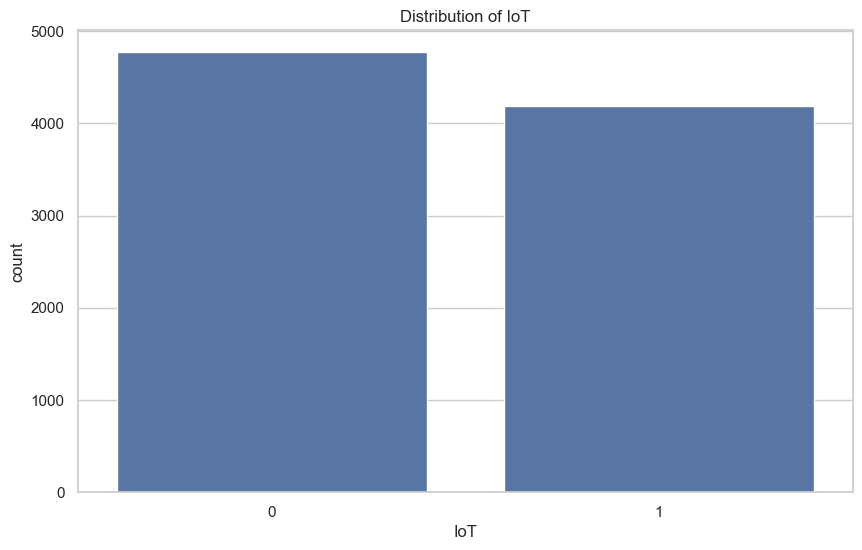

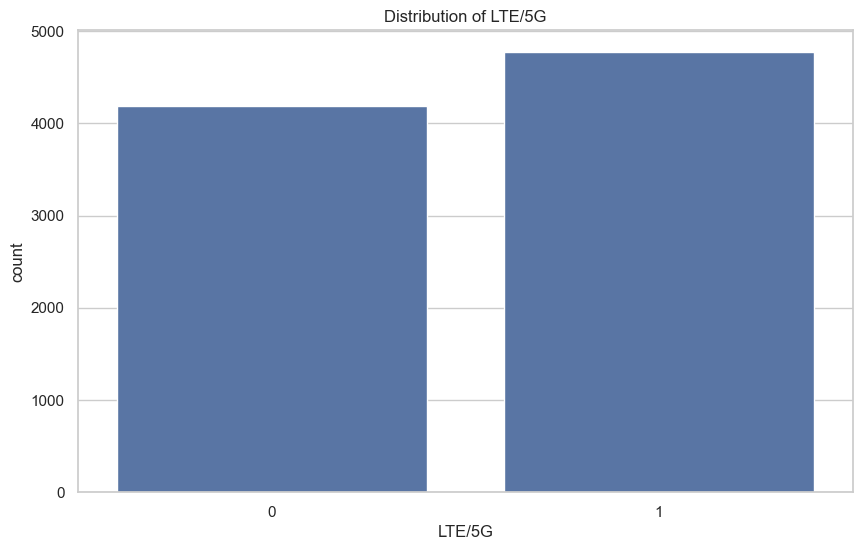

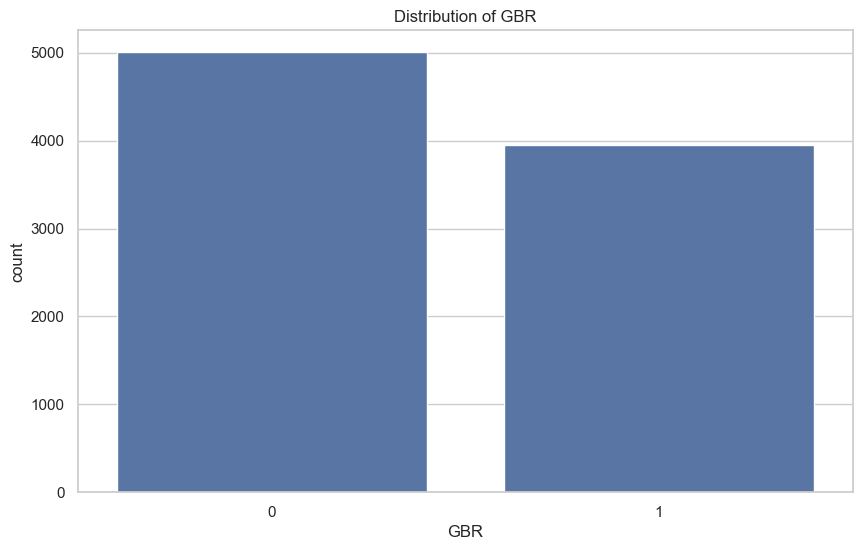

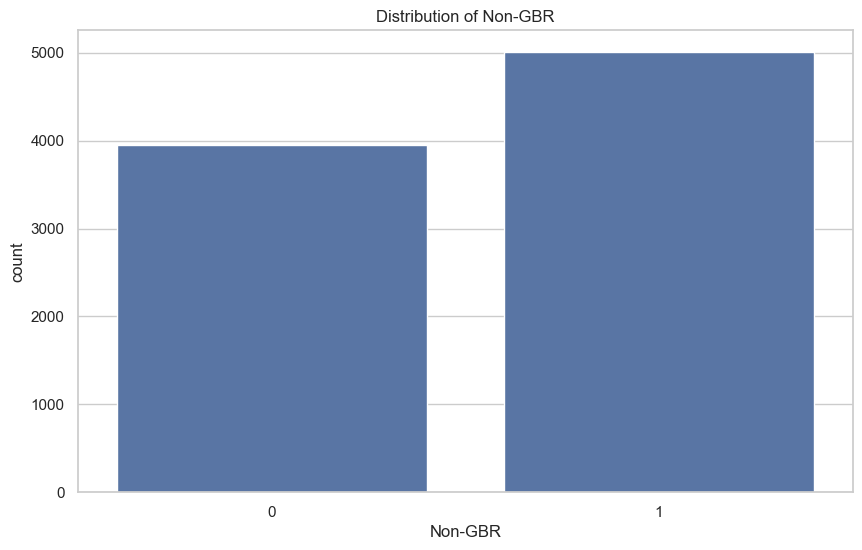

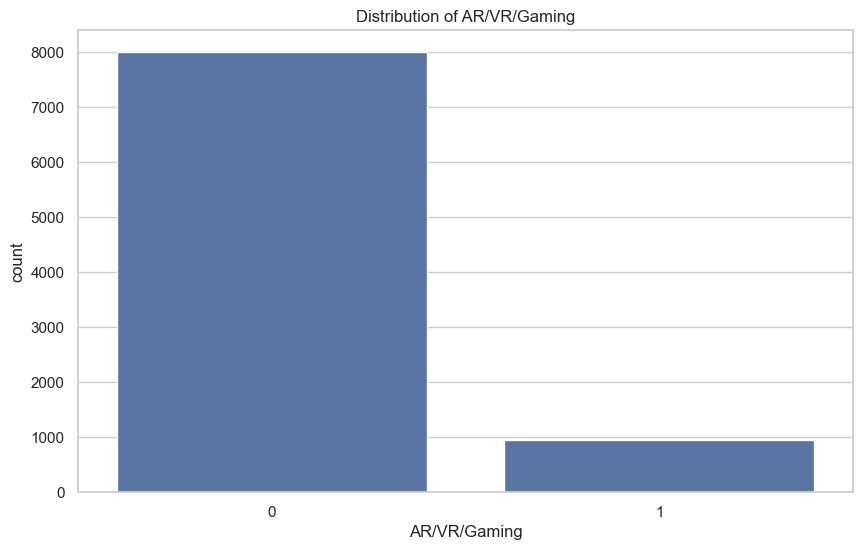

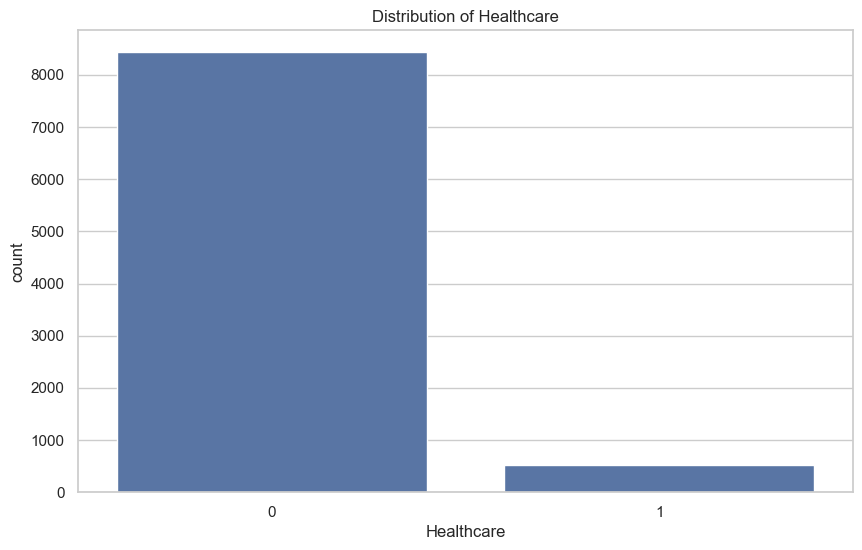

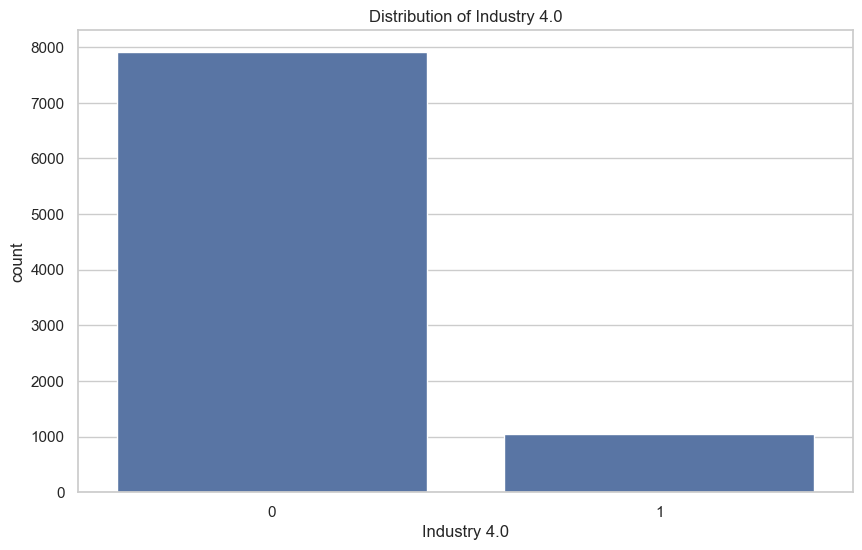

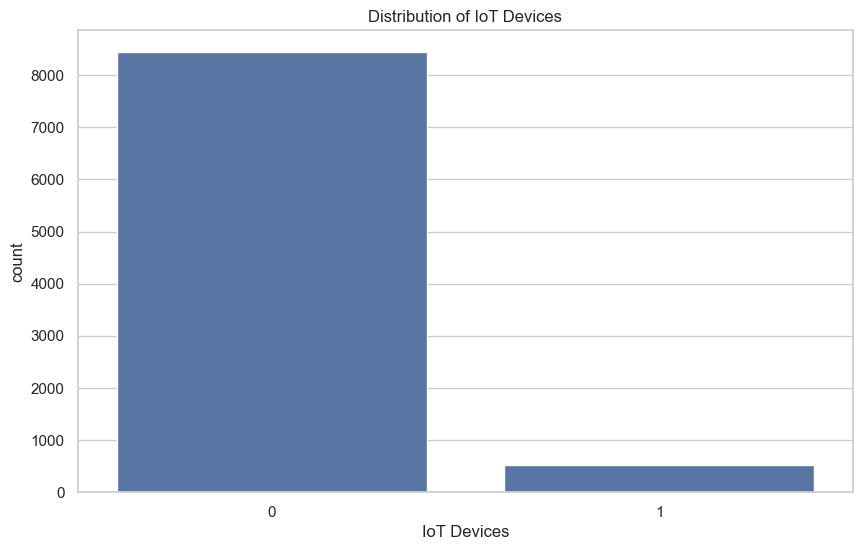

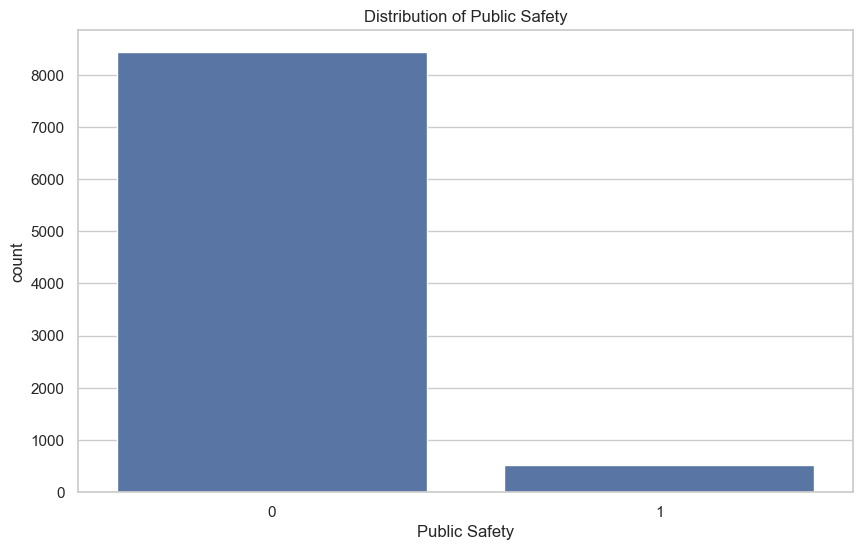

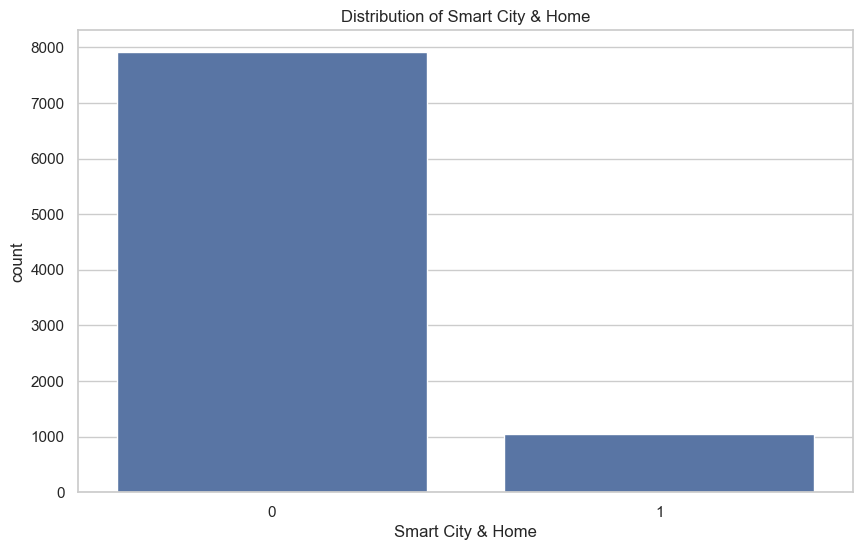

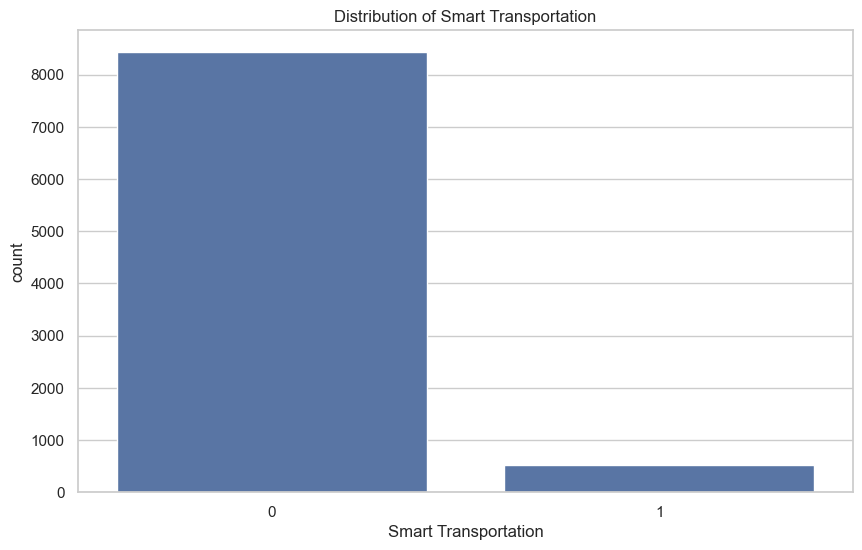

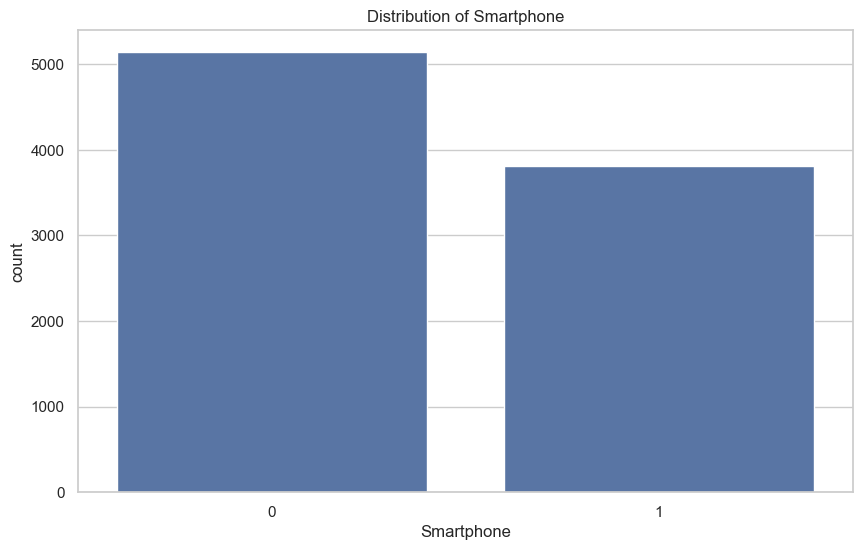

In [ ]:
binary_features = train_df.columns.drop(
    ["slice Type", "Time", "Packet Loss Rate", "Packet delay", "LTE/5g Category"]
)

for col in binary_features:
    sns.countplot(x=col, data=train_df)
    plt.title(f"Distribution of {col}")
    plt.show()


# STEP 10 — Correlation Analysis

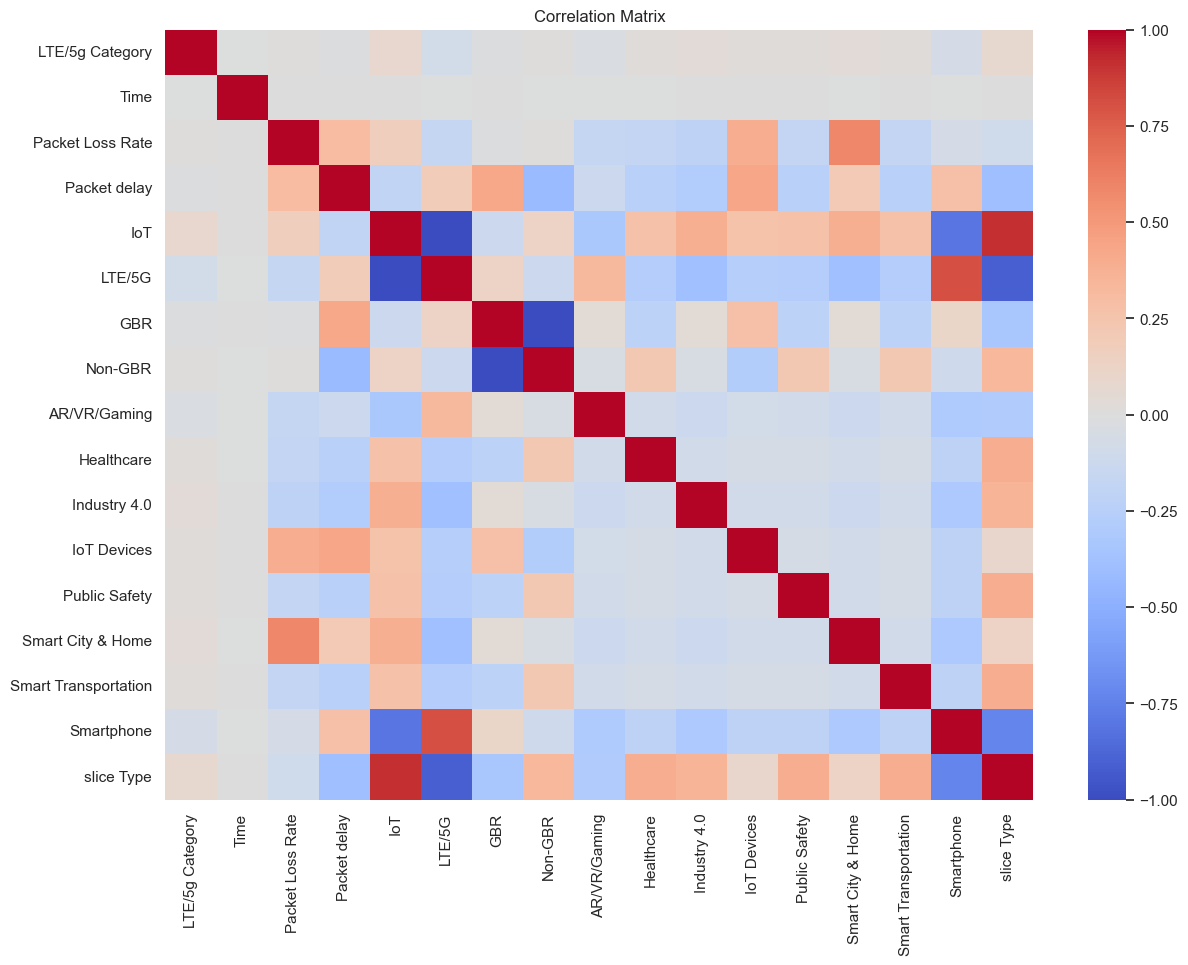

In [ ]:
corr_matrix = train_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Matrix")
plt.show()


# STEP 11 — Feature vs Target Analysis

# Packet Delay vs Slice Type

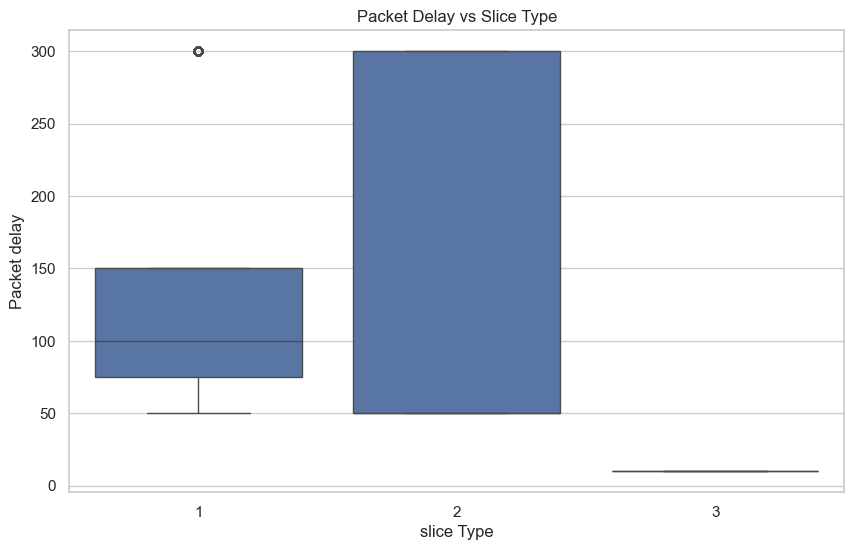

In [ ]:
sns.boxplot(x="slice Type", y="Packet delay", data=train_df)
plt.title("Packet Delay vs Slice Type")
plt.show()


# Packet Loss Rate vs Slice Type

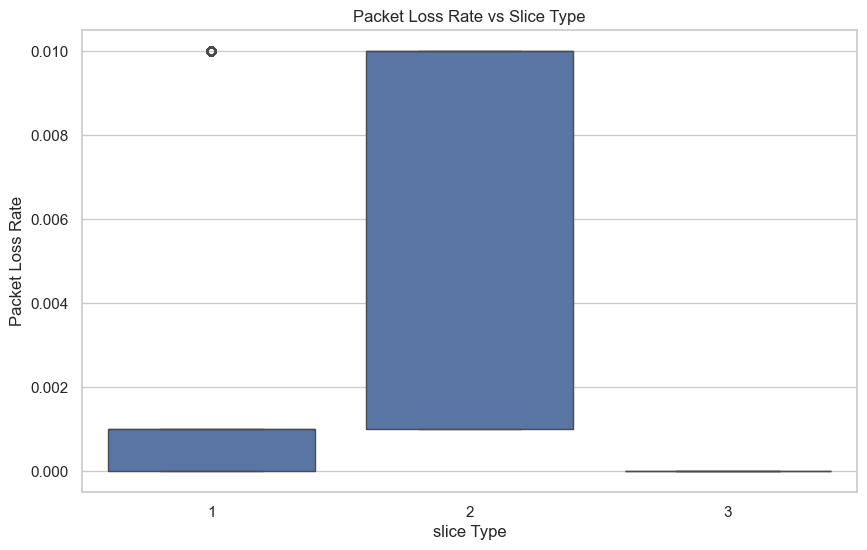

In [ ]:
sns.boxplot(x="slice Type", y="Packet Loss Rate", data=train_df)
plt.title("Packet Loss Rate vs Slice Type")
plt.show()


# STEP 12 — Train vs Test Comparison

In [ ]:
train_df.describe().loc[["mean", "std"]] - test_df.describe().loc[["mean", "std"]]


,AR/VR/Gaming,GBR,Healthcare,Industry 4.0,IoT,IoT Devices,LTE/5G,LTE/5g Category,Non-GBR,Packet Loss Rate,Packet delay,Public Safety,Smart City & Home,Smart Transportation,Smartphone,Time,slice Type
mean,0.000242,-0.000524,-0.000585,-0.001061,-0.000793,-0.001207,0.000793,0.009301,0.000524,-0.000019,-0.307870,0.001188,0.000331,0.000541,0.000551,-0.014081,NaN
std,0.000321,-0.000042,-0.001089,-0.001248,-0.000031,-0.002260,-0.000031,-0.012650,-0.000042,-0.000008,-0.086403,0.002258,0.000408,0.001027,0.000103,-0.004200,NaN


# STEP 13 — Outlier Detection

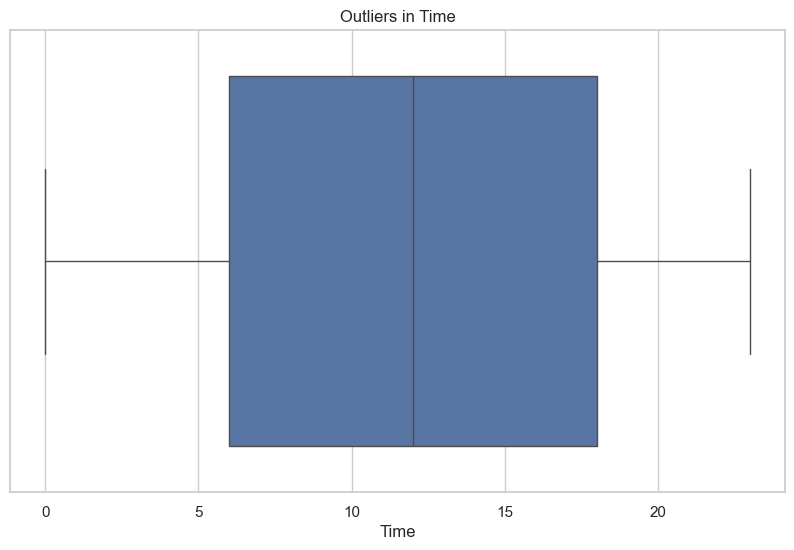

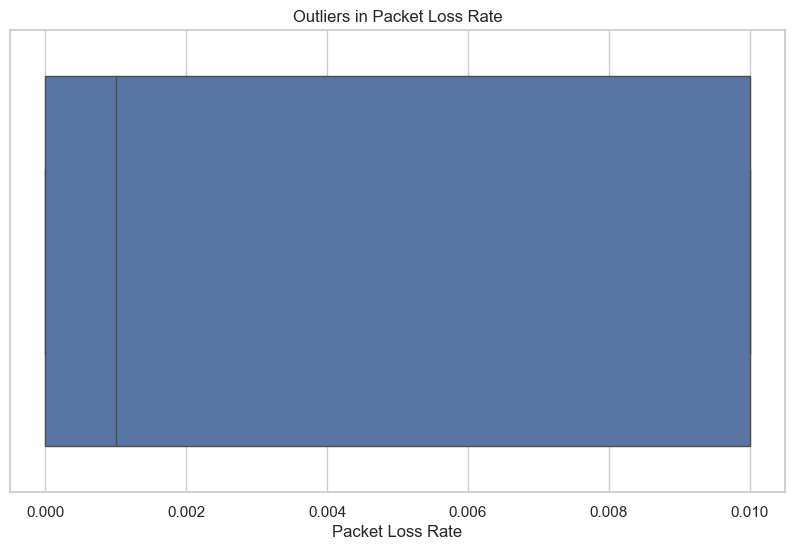

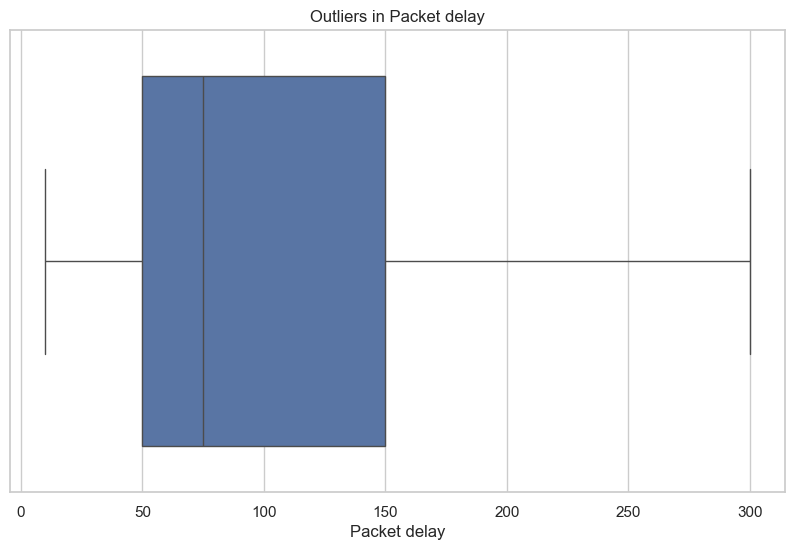

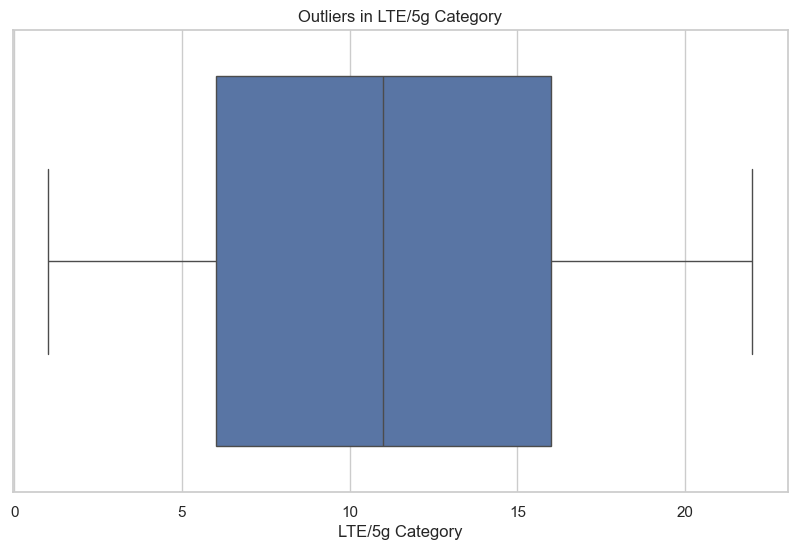

In [ ]:
# Enhanced Outlier Detection with Better Visibility
from scipy import stats

# Create a comprehensive outlier analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Enhanced Outlier Detection Analysis', fontsize=16, fontweight='bold')

for i, col in enumerate(numerical_features):
    row, col_idx = i // 2, i % 2
    
    # Calculate outliers using IQR method
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = train_df[(train_df[col] < lower_bound) | (train_df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_percentage = (outlier_count / len(train_df)) * 100
    
    # Enhanced boxplot with outlier points highlighted
    sns.boxplot(x=train_df[col], ax=axes[row, col_idx], color='lightblue', 
                boxprops=dict(alpha=0.7), whiskerprops=dict(linewidth=2))
    
    # Add outlier points in red
    if outlier_count > 0:
        sns.stripplot(x=outliers[col], ax=axes[row, col_idx], 
                     color='red', size=8, alpha=0.8, jitter=True)
    
    # Enhanced title with statistics
    axes[row, col_idx].set_title(
        f'{col}\n'
        f'Outliers: {outlier_count} ({outlier_percentage:.2f}%)\n'
        f'Range: [{lower_bound:.2f}, {upper_bound:.2f}]',
        fontsize=12, fontweight='bold'
    )
    axes[row, col_idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Detailed outlier summary table
print("\n" + "="*80)
print("DETAILED OUTLIER ANALYSIS SUMMARY")
print("="*80)

outlier_summary = []

for col in numerical_features:
    # IQR method
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers_iqr = train_df[(train_df[col] < lower_bound) | (train_df[col] > upper_bound)]
    
    # Z-score method (alternative)
    z_scores = np.abs(stats.zscore(train_df[col]))
    outliers_zscore = train_df[z_scores > 3]
    
    # Statistics
    outlier_summary.append({
        'Feature': col,
        'Total_Values': len(train_df),
        'IQR_Outliers': len(outliers_iqr),
        'IQR_Percentage': (len(outliers_iqr) / len(train_df)) * 100,
        'ZScore_Outliers': len(outliers_zscore),
        'ZScore_Percentage': (len(outliers_zscore) / len(train_df)) * 100,
        'Min_Value': train_df[col].min(),
        'Max_Value': train_df[col].max(),
        'Mean': train_df[col].mean(),
        'Std': train_df[col].std(),
        'IQR_Lower_Bound': lower_bound,
        'IQR_Upper_Bound': upper_bound
    })

# Create summary DataFrame
summary_df = pd.DataFrame(outlier_summary)
print(summary_df.to_string(index=False, float_format='%.3f'))

# Visual outlier distribution comparison
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle('Outlier Distribution Comparison', fontsize=16, fontweight='bold')

for i, col in enumerate(numerical_features):
    # Separate normal and outlier data
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    normal_data = train_df[(train_df[col] >= lower_bound) & (train_df[col] <= upper_bound)][col]
    outlier_data = train_df[(train_df[col] < lower_bound) | (train_df[col] > upper_bound)][col]
    
    # Plot histogram with outlier highlighting
    axes[i].hist(normal_data, bins=30, alpha=0.7, color='lightblue', label='Normal Data')
    if len(outlier_data) > 0:
        axes[i].hist(outlier_data, bins=20, alpha=0.8, color='red', label='Outliers')
    
    axes[i].set_title(f'{col}\nNormal: {len(normal_data)} | Outliers: {len(outlier_data)}', 
                     fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("OUTLIER DETECTION COMPLETE")
print("="*80)